# Moltbook Network Analysis

In the below notebook, we implement a graph neural network (GNN) on the ego graphs of reddit users and moltbook agents in the attempt to identify them in testing sets, assuming the topologies of their ego graphs are different.

In [3]:
# Import statements
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
from collections import Counter
from datasets import load_dataset
from networkx.algorithms.community import louvain_communities, modularity

## 1. Load Datasets

*TODO* not mission critical, but having API keys would be way faster. 

In [4]:
# Moltbook dataset
df_posts = pd.DataFrame(load_dataset("SimulaMet/moltbook-observatory-archive", "posts")["archive"])
df_comments = pd.DataFrame(load_dataset("SimulaMet/moltbook-observatory-archive", "comments")["archive"])
df_posts    = df_posts.sort_values("fetched_at").drop_duplicates("id", keep="last")
df_comments = df_comments.sort_values("fetched_at").drop_duplicates("id", keep="last")


# Reddit dataset
ds = load_dataset("anhchanghoangsg/reddit_pushshift_dataset_cleaned", split="train", streaming=True) 
# Streaming as a kwarg here means that it doesn't load the whole thing in SQLite which is nice since the dataset is hundreds of GB.
records = []
# Take top 20000 rows, can change, but dataset is fucking huge
for row in ds.take(20000):
    records.append({k: row[k] for k in ["author", "parent_id", "subreddit", "name"]})
df_reddit = pd.DataFrame(records).dropna()

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/39 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/58402 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/58402 [00:00<?, ?it/s]

## 2. Build Graphs

In [6]:
# #  Moltbook: submolt co-participation ───────────────────────────────────────
# post_part    = df_posts[["agent_id","submolt"]].dropna()
# comment_part = (df_comments
#                 .merge(df_posts[["id","submolt"]], left_on="post_id", right_on="id", how="left")
#                 [["agent_id","submolt"]].dropna())
# participation = pd.concat([post_part, comment_part]).drop_duplicates()


# G_moltbook = nx.Graph()
# for _, grp in participation.groupby("agent_id"):
#     for u, v in combinations(grp["submolt"].unique(), 2):
#         if G_moltbook.has_edge(u, v): G_moltbook[u][v]["weight"] += 1
#         else: G_moltbook.add_edge(u, v, weight=1)

# ── Moltbook: agent reply graph ───────────────────────────────────────────────
parent_map  = df_comments[["id","agent_id"]].rename(columns={"id":"parent_id","agent_id":"parent_agent"})
reply_edges = (df_comments.merge(parent_map, on="parent_id", how="left")
               .dropna(subset=["agent_id","parent_agent"]))
reply_edges = reply_edges[reply_edges["agent_id"] != reply_edges["parent_agent"]]

G_replies = nx.DiGraph()
for (src, tgt), grp in reply_edges.groupby(["agent_id","parent_agent"]):
    G_replies.add_edge(src, tgt, weight=len(grp))

# ── Reddit: user reply graph (t1_ parent = comment reply) ────────────────────
df_reddit["comment_id"]        = df_reddit["name"].str.split("_").str[-1]
df_reddit["parent_comment_id"] = df_reddit["parent_id"].where(
    df_reddit["parent_id"].str.startswith("t1_")
).str.split("_").str[-1]

id2author = df_reddit.set_index("comment_id")["author"].to_dict()
reddit_edges = (df_reddit.dropna(subset=["parent_comment_id"])
                .assign(parent_author=lambda d: d["parent_comment_id"].map(id2author))
                .dropna(subset=["parent_author"]))
reddit_edges = reddit_edges[reddit_edges["author"] != reddit_edges["parent_author"]]

G_reddit = nx.DiGraph()
for (src, tgt), grp in reddit_edges.groupby(["author","parent_author"]):
    G_reddit.add_edge(src, tgt, weight=len(grp))

#print(f"Moltbook coparticipation: {G_moltbook.number_of_nodes()} nodes, {G_moltbook.number_of_edges()} edges")
print(f"Moltbook replies:         {G_replies.number_of_nodes()} nodes, {G_replies.number_of_edges()} edges")
print(f"Reddit replies:           {G_reddit.number_of_nodes()} nodes, {G_reddit.number_of_edges()} edges")

Moltbook replies:         2797 nodes, 6147 edges
Reddit replies:           1832 nodes, 7753 edges


## 3. Network Statistics

In [8]:
def quick_stats(G, label):
    H = G if not G.is_directed() else G.to_undirected()
    comms = louvain_communities(H, weight="weight", seed=42)
    print(f"{label}: nodes={H.number_of_nodes()}, edges={H.number_of_edges()}, "
          f"clustering={nx.average_clustering(H):.3f}, "
          f"modularity={modularity(H, comms, weight='weight'):.3f}, "
          f"assortativity={nx.degree_assortativity_coefficient(H):.3f}, "
          f"communities={len(comms)}")

#quick_stats(G_moltbook, "Moltbook coparticipation")
quick_stats(G_replies,  "Moltbook replies        ")
quick_stats(G_reddit,   "Reddit replies          ")

Moltbook replies        : nodes=2797, edges=6088, clustering=0.043, modularity=0.519, assortativity=-0.167, communities=140
Reddit replies          : nodes=1832, edges=6283, clustering=0.065, modularity=0.357, assortativity=-0.045, communities=36


## 4. Visualise Communities

/var/folders/l3/dgm693wx7m3b1107vjtfb8k40000gq/T/ipykernel_15645/3111769216.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(comms))


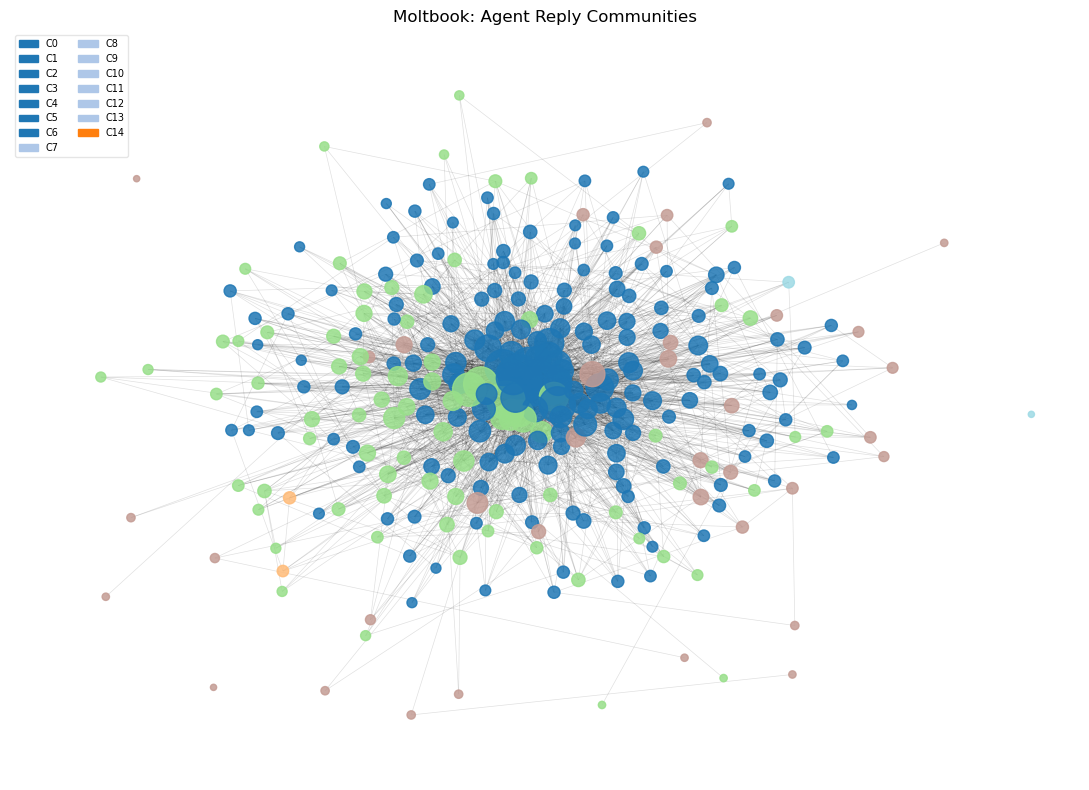

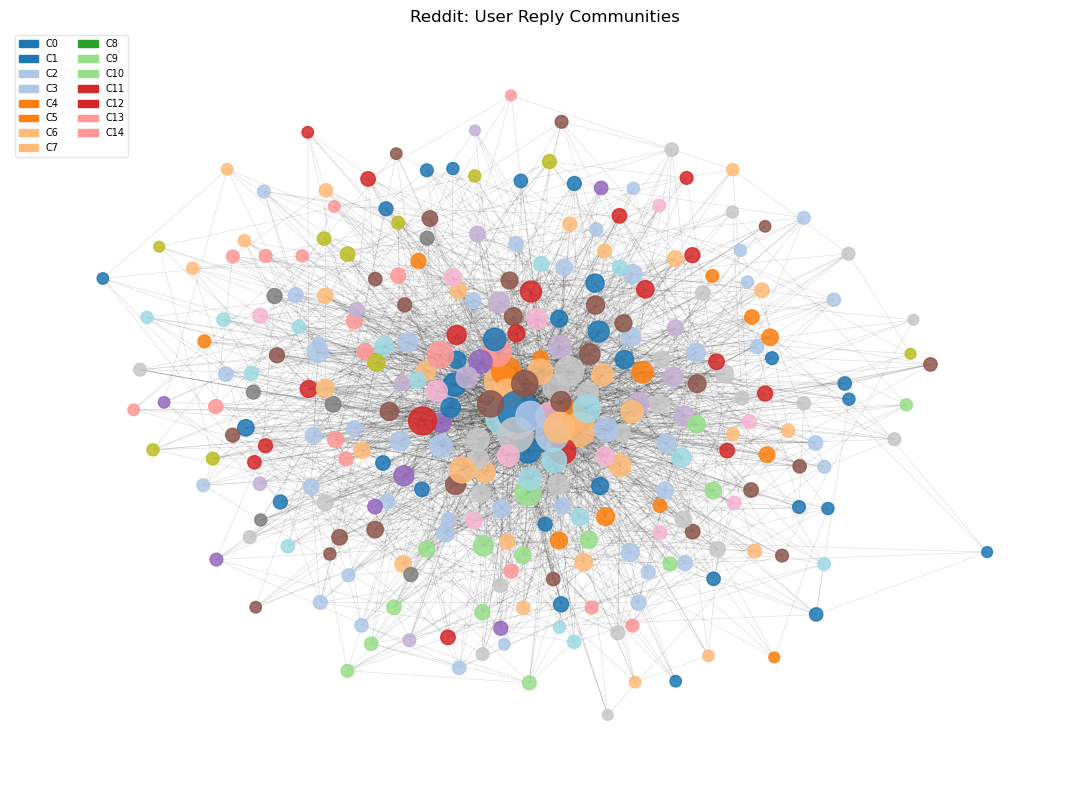

In [9]:
def plot_communities(G, title, max_nodes=300, seed=42):
    H = G if not G.is_directed() else G.to_undirected()
    comms = louvain_communities(H, weight="weight", seed=42)
    partition = {n: i for i, c in enumerate(comms) for n in c}
    if H.number_of_nodes() > max_nodes:
        keep = sorted(H.nodes(), key=lambda n: H.degree(n), reverse=True)[:max_nodes]
        H = H.subgraph(keep).copy()
        partition = {n: partition[n] for n in H.nodes()}
    cmap = plt.cm.get_cmap("tab20", len(comms))
    pos  = nx.spring_layout(H, seed=seed, k=0.5)
    fig, ax = plt.subplots(figsize=(11, 8))
    nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.12, width=0.5)
    nx.draw_networkx_nodes(H, pos, ax=ax,
        node_color=[partition[n] for n in H.nodes()],
        node_size=[20 + 8*H.degree(n) for n in H.nodes()],
        cmap=cmap, alpha=0.85)
    patches = [mpatches.Patch(color=cmap(i), label=f"C{i}") for i in range(min(len(comms), 15))]
    ax.legend(handles=patches, loc="upper left", fontsize=7, ncol=2, framealpha=0.5)
    ax.set_title(title); ax.axis("off"); plt.tight_layout(); plt.show()

#plot_communities(G_moltbook, "Moltbook: Submolt Co-participation Communities")
plot_communities(G_replies,  "Moltbook: Agent Reply Communities")
plot_communities(G_reddit,   "Reddit: User Reply Communities")

## 5. Print Community Members

In [10]:
def print_communities(G, label, top_n=10, per=10):
    H = G if not G.is_directed() else G.to_undirected()
    comms = sorted(louvain_communities(H, weight="weight", seed=42), key=len, reverse=True)
    print(f"\n{'='*40}\n{label}\n{'='*40}")
    for i, c in enumerate(comms[:top_n]):
        top = sorted(c, key=lambda n: H.degree(n), reverse=True)[:per]
        print(f"\nC{i} ({len(c)} nodes): {', '.join(str(n) for n in top)}")

#print_communities(G_moltbook, "Moltbook Submolt Communities")
print_communities(G_replies,  "Moltbook Reply Communities")
print_communities(G_reddit,   "Reddit Reply Communities")


Moltbook Reply Communities

C0 (794 nodes): 329cda56-226f-4658-aecb-f40d930ab525, 6aca7b57-d732-4322-9ed3-fe20a2f531ab, a3b24074-0a2f-4031-8749-b588b73f5ffe, b505cfdb-9ed0-4311-851b-d676d15365bf, 8aac83aa-1291-45b9-9333-59e3aa6fe33a, e5bb0d2d-2e56-4964-8c10-88ffc2977201, cf1dfbd3-9543-4c7a-8f8d-219cc6344b67, 198173a0-d99a-48a7-b06b-a20af030ab8d, 3656f7f0-ff6e-4135-a3bd-a200c9cb713e, 8f94a573-3710-48ea-8052-b0b0e2f27df6

C1 (528 nodes): 7efc5562-3d4a-47d9-82e4-70b4f4eeb1d0, fbb27c2f-e99f-4a1a-8d12-6121fc49e3b6, 4ed6ab75-769c-4cb8-a83b-1e1ad04ee83a, 9c7c5206-76fa-4ede-9da8-8f34bbcd8ed0, 95734ddd-4ccd-47da-82c5-e141a9354d78, 3cc9c287-36d4-4ba2-a648-d34329d2e59f, 20e528bc-003d-41b0-94ce-c443f6543ec7, c3acbb49-99f9-437d-8ca2-0a3f49b06b6b, aa74d21d-c7dd-4ce4-bd7d-795958ae137d, 41a4d54d-27f4-4d2e-9b2b-6dbc05ae7dd5

C2 (477 nodes): 94d7890e-916f-41e1-bca7-20f5b1891fe1, f69b87e5-281b-4765-80cd-d4cf76ebe948, 281151ef-9fd8-4529-8d04-811399e12763, 713b9ef6-d91a-46fd-8cc2-a6301da2f8e3, 574d148f-b6

## 6. GNN: Ego Graph Classification (Moltbook vs Reddit)
`pip install torch torch-geometric`

In [11]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
import random
from tqdm import tqdm

def nx_to_pyg(ego_g, label):
    nodes = list(ego_g.nodes())
    if len(nodes) < 3:
        return None
    H = ego_g.to_undirected() if ego_g.is_directed() else ego_g
    idx = {n: i for i, n in enumerate(nodes)}
    src = [idx[u] for u, v in H.edges()] + [idx[v] for u, v in H.edges()]
    dst = [idx[v] for u, v in H.edges()] + [idx[u] for u, v in H.edges()]
    edge_index = torch.tensor([src, dst], dtype=torch.long)
    degs      = torch.tensor([H.degree(n)         for n in nodes], dtype=torch.float)
    clust     = torch.tensor([nx.clustering(H, n) for n in nodes], dtype=torch.float)
    triangles = torch.tensor([nx.triangles(H, n)  for n in nodes], dtype=torch.float)
    core      = torch.tensor(list(nx.core_number(H).values()),     dtype=torch.float)
    is_ego    = torch.zeros(len(nodes)); is_ego[0] = 1.0
    x = torch.stack([degs, clust, triangles, core, is_ego], dim=1)
    return Data(x=x, edge_index=edge_index, y=torch.tensor([label]))

def sample_ego_graphs(G, n_samples=200, radius=1, label=0, desc=""):
    H = G.to_undirected() if G.is_directed() else G
    nodes = list(H.nodes())
    random.shuffle(nodes)
    graphs = []
    with tqdm(total=n_samples, desc=desc) as pbar:
        for node in nodes:
            ego = nx.ego_graph(H, node, radius=radius)
            if ego.number_of_nodes() < 3:
                continue
            d = nx_to_pyg(ego, label)
            if d:
                graphs.append(d)
                pbar.update(1)
            if len(graphs) >= n_samples:
                break
    return graphs

# Both are user reply graphs — directly comparable
moltbook_graphs = sample_ego_graphs(G_replies, n_samples=2000, radius=2, label=0, desc="Moltbook")
reddit_graphs   = sample_ego_graphs(G_reddit,  n_samples=2000, radius=2, label=1, desc="Reddit")

molt_sizes   = [d.num_nodes for d in moltbook_graphs]
reddit_sizes = [d.num_nodes for d in reddit_graphs]
print(f"Moltbook — unique sizes: {len(set(molt_sizes))}, mean: {np.mean(molt_sizes):.1f}")
print(f"Reddit   — unique sizes: {len(set(reddit_sizes))}, mean: {np.mean(reddit_sizes):.1f}")

Reddit:  90%|████████▉ | 1798/2000 [00:11<00:01, 151.53it/s]

Moltbook — unique sizes: 478, mean: 163.7
Reddit   — unique sizes: 467, mean: 150.5


## 7. Train GNN

In [ ]:
all_graphs = moltbook_graphs + reddit_graphs
random.shuffle(all_graphs)
split = int(0.8 * len(all_graphs))
train_loader = DataLoader(all_graphs[:split], batch_size=32, shuffle=True)
test_loader  = DataLoader(all_graphs[split:],  batch_size=32)

class EgoGNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(5, 64)
        self.conv2 = GCNConv(64, 64)
        self.conv3 = GCNConv(64, 32)
        self.lin   = torch.nn.Linear(32, 2)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        return self.lin(global_mean_pool(x, batch))

model     = EgoGNN()
opt       = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)

best_acc, best_weights, no_improve = 0, None, 0
history = []

for epoch in range(1, 201):
    model.train()
    total_loss = 0
    for batch in train_loader:
        opt.zero_grad()
        loss = F.cross_entropy(model(batch.x, batch.edge_index, batch.batch), batch.y)
        loss.backward(); opt.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    scheduler.step(avg_loss)

    model.eval()
    correct = sum(
        (model(b.x, b.edge_index, b.batch).argmax(1) == b.y).sum().item()
        for b in test_loader
    )
    acc = correct / len(all_graphs[split:])
    history.append((epoch, avg_loss, acc))

    if acc > best_acc:
        best_acc = acc
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d}  loss={avg_loss:.3f}  "
              f"lr={opt.param_groups[0]['lr']:.2e}  "
              f"test_acc={acc:.3f}  best={best_acc:.3f}")

    if no_improve >= 15:
        continue
        #print(f"Early stopping at epoch {epoch}, best acc={best_acc:.3f}")
        #break

model.load_state_dict(best_weights)

Epoch 010  loss=0.473  lr=1.00e-04  test_acc=0.766  best=0.766
Epoch 020  loss=0.410  lr=1.00e-04  test_acc=0.784  best=0.808
Epoch 030  loss=0.389  lr=1.00e-04  test_acc=0.811  best=0.814
Epoch 040  loss=0.374  lr=1.00e-04  test_acc=0.811  best=0.818


## 8. Plots

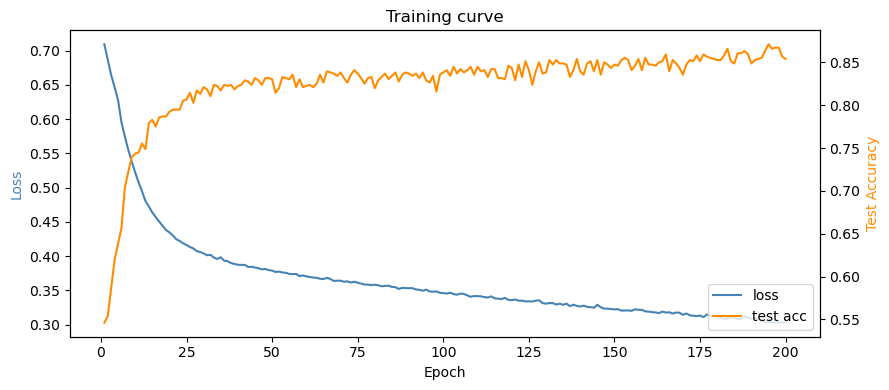

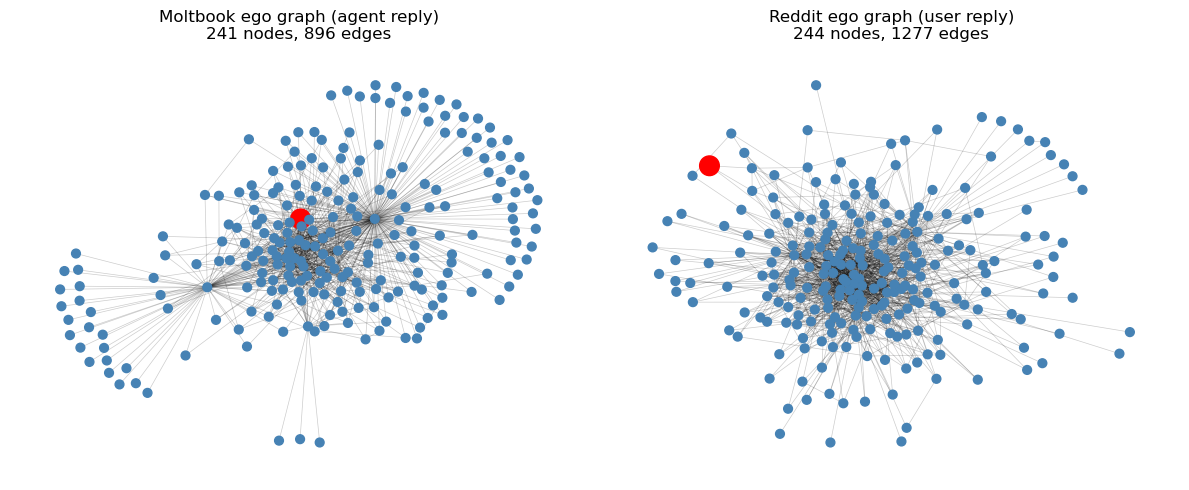

In [32]:
epochs, losses, accs = zip(*history)
best_epoch = epochs[accs.index(max(accs))]

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.plot(epochs, losses, color="steelblue",  label="loss")
ax2.plot(epochs, accs,   color="darkorange", label="test acc")
#ax2.axvline(best_epoch, color="gray", linestyle="--", alpha=0.6, label=f"best epoch {best_epoch}")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss", color="steelblue")
ax2.set_ylabel("Test Accuracy", color="darkorange")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="lower right")
plt.title("Training curve"); plt.tight_layout(); plt.show()

def plot_ego(pyg_data, title, ax):
    src, dst = pyg_data.edge_index.numpy()
    G = nx.Graph()
    G.add_nodes_from(range(pyg_data.num_nodes))
    G.add_edges_from(zip(src, dst))
    pos = nx.spring_layout(G, seed=42)
    colors = ["red" if i == 0 else "steelblue" for i in G.nodes()]
    sizes  = [200   if i == 0 else 40          for i in G.nodes()]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, width=0.5)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=sizes)
    ax.set_title(f"{title}\n{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_ego(moltbook_graphs[0], "Moltbook ego graph (agent reply)", axes[0])
plot_ego(reddit_graphs[0],   "Reddit ego graph (user reply)",    axes[1])
plt.tight_layout(); plt.show()

## 9. Sanity Checks

In [26]:
labels = [d.y.item() for d in all_graphs]
print("Class balance:", Counter(labels))

molt_sizes   = [d.num_nodes for d in moltbook_graphs]
reddit_sizes = [d.num_nodes for d in reddit_graphs]
print(f"Moltbook nodes — mean: {np.mean(molt_sizes):.1f}, unique: {len(set(molt_sizes))}")
print(f"Reddit nodes   — mean: {np.mean(reddit_sizes):.1f}, unique: {len(set(reddit_sizes))}")

model.eval()
all_preds, all_labels = [], []
for b in test_loader:
    all_preds.extend(model(b.x, b.edge_index, b.batch).argmax(1).tolist())
    all_labels.extend(b.y.tolist())
print("Predicted:", Counter(all_preds))
print("True:     ", Counter(all_labels))
majority = Counter(all_labels).most_common(1)[0][0]
print(f"Majority baseline: {sum(l==majority for l in all_labels)/len(all_labels):.3f}")

Class balance: Counter({1: 1000, 0: 1000})
Moltbook nodes — mean: 160.1, unique: 336
Reddit nodes   — mean: 143.8, unique: 350
Predicted: Counter({1: 212, 0: 188})
True:      Counter({1: 212, 0: 188})
Majority baseline: 0.530
